# K-Means 1 Manual Implementation

- Pedro Mauri Mtz - A01029143

K-Means (Not supervised training)

## Imports

In [3]:
import random
import math
import matplotlib.pyplot as plt
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), "../"))

## Load Data

In [4]:
x = []

"""
Leer archivo de datos
"""
with open(os.path.join(ROOT, "Datasets/ex7data2.txt"), "r") as file:
    for line in file:
        stripped_line = line.strip()

        if stripped_line:
            col1, col2 = stripped_line.split()
            x.append([float(col1), float(col2)])

## Functions

In [5]:
"""
Función que grafica los puntos coloreados por cluster y sus centroides:
"""
def plot_clusters(x, idx, c):
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

    for k in range(len(c)):
        xs = [x[i][0] for i in range(len(x)) if idx[i] == k]
        ys = [x[i][1] for i in range(len(x)) if idx[i] == k]
        plt.scatter(xs, ys, color = colors[k % len(colors)], s = 15, label = f'Cluster {k + 1}')

    plt.scatter([ck[0] for ck in c], [ck[1] for ck in c],
                color = 'black', marker = 'x', s = 150, linewidths = 3, label = 'Centroids')

    plt.title('K-Means Clustering')
    plt.legend()
    plt.xlabel('Eje x1')
    plt.ylabel('Eje x2')
    plt.grid(True)
    plt.show()

In [6]:
"""
Distancia euclidiana
"""
def euclideanDistance(list1, list2):
    sumList = 0
    
    for x, y in zip(list1, list2):
        sumList += ((x - y) ** 2)
    
    return math.sqrt(sumList)

## K-Means Implementation

In [7]:
"""
Asigna cada punto al centroide más cercano
"""
def findClosestCentroids(x, c):
    idx = []

    for point in x:
        distances = [euclideanDistance(point, centroid) for centroid in c]
        idx.append(distances.index(min(distances)))

    return idx


"""
Recalcula cada centroide como la media de los puntos asignados a su cluster
"""
def computeCentroids(x, idx, c):
    new_c = []

    for k in range(len(c)):
        points = [x[i] for i in range(len(x)) if idx[i] == k]

        if points:
            n = len(points)
            new_c.append([sum(p[0] for p in points) / n, sum(p[1] for p in points) / n])
        else:
            # Cluster vacío: se conserva el centroide anterior
            new_c.append(c[k])

    return new_c


"""
Distorsión J: promedio de la distancia al cuadrado entre cada punto y su centroide
"""
def computeDistortion(x, idx, c):
    return sum(euclideanDistance(x[i], c[idx[i]]) ** 2 for i in range(len(x))) / len(x)

## Training loop

In [8]:
K = 3

initial_c = random.sample(x, K)

print(initial_c)

[[3.083491363119661, 1.196326444356825], [7.756605593713768, 3.15604464618241], [2.541800105726059, 4.810987375514933]]


In [9]:
epochs = 100

c = initial_c
history = []

for epoch in range(epochs):
    # 1. Asignar cada punto a su centroide más cercano
    idx = findClosestCentroids(x, c)

    # 2. Distorsión con los centroides actuales
    history.append(computeDistortion(x, idx, c))

    # 3. Recalcular centroides
    new_c = computeCentroids(x, idx, c)

    # 4. Si ya no cambian, el algoritmo convergió
    if new_c == c:
        print(f"Convergió en la epoch {epoch + 1}")
        break

    c = new_c

print("Centroides finales:", c)

Convergió en la epoch 4
Centroides finales: [[3.0436711927398132, 1.0154104079486548], [6.033667356017604, 3.0005251118352567], [1.953994664859387, 5.025570059426877]]


## Results

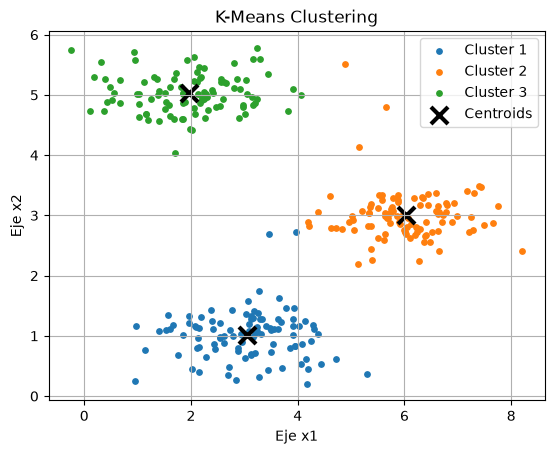

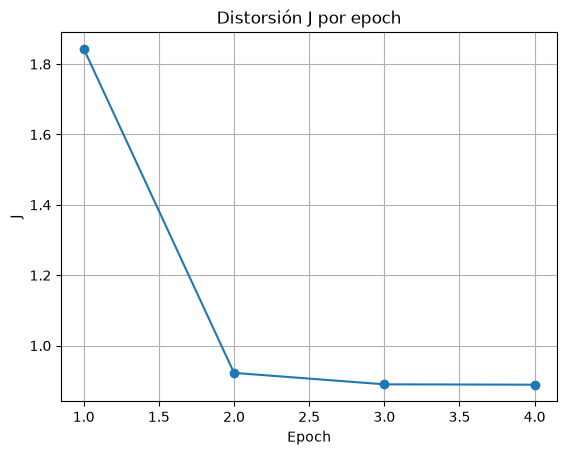

In [10]:
plot_clusters(x, idx, c)

plt.plot(range(1, len(history) + 1), history, marker = 'o')
plt.title('Distorsión J por epoch')
plt.xlabel('Epoch')
plt.ylabel('J')
plt.grid(True)
plt.show()